In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import wilcoxon, ttest_rel
import os

In [2]:
# ============================================================
# Fonts / plotting defaults
# ============================================================
import matplotlib.font_manager as fm

font_paths = [
    "/home/gzu5140/Font/Arial.ttf",
    "/home/gzu5140/Font/Arial Bold.ttf",
    "/home/gzu5140/Font/Arial Italic.ttf",
    "/home/gzu5140/Font/Arial Bold Italic.ttf",
]
for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)

plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['axes.titlesize'] = 26
plt.rcParams['xtick.labelsize'] = 24
plt.rcParams['ytick.labelsize'] = 24
plt.rcParams['legend.fontsize'] = 24
plt.rcParams['figure.dpi'] = 400
plt.rcParams['axes.grid'] = False

✔ Loaded font: /home/gzu5140/Font/Arial.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Italic.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold Italic.ttf


In [3]:
#Path to the plot data
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_4/"
path_to_plots = "/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_4/"
os.makedirs(path_to_plots, exist_ok = True)

## Figure 4a

In [12]:
#!/usr/bin/env python3
def discover_motif_files(roots, rules, pattern="df*.csv", recursive=False, sort_by="mtime"):
    """
    Discover df*.csv files in roots, then assign them to motifs using ONLY filename checks.

    rules[motif]:
      - include_all: list[str] (filename must contain ALL substrings)  [AND]
      - exclude_any: list[str] (filename must contain NONE of these)
      - max_files: int|None    (keep newest N if sort_by='mtime')
    """
    candidates = []
    for root in roots:
        if recursive:
            candidates += glob.glob(os.path.join(root, "**", pattern), recursive=True)
        else:
            candidates += glob.glob(os.path.join(root, pattern))

    # de-dup and keep real files
    candidates = [p for p in dict.fromkeys(candidates) if p and os.path.isfile(p)]

    def _key(p):
        if sort_by == "name":
            return os.path.basename(p).lower()
        return os.path.getmtime(p)  # default: mtime

    out = {}
    for motif, r in rules.items():
        inc_all = [s.lower() for s in r.get("include_all", [])]
        exc_any = [s.lower() for s in r.get("exclude_any", [])]
        max_files = r.get("max_files", None)

        hits = []
        for p in candidates:
            name = os.path.basename(p).lower()

            # AND filter: must contain ALL required substrings
            if inc_all and not all(k in name for k in inc_all):
                continue

            # exclusions: must contain NONE of these
            if exc_any and any(k in name for k in exc_any):
                continue

            hits.append(p)

        if sort_by == "name":
            hits = sorted(hits, key=_key)
        else:
            hits = sorted(hits, key=_key, reverse=True)  # newest first

        if isinstance(max_files, int) and max_files > 0:
            hits = hits[:max_files]

        out[motif] = hits
        print(f"[discover] {motif}: {len(hits)} files")
        if hits:
            print("  example:", os.path.basename(hits[0]))

    return out

# ============================================================
# Aggregate
# ============================================================
def aggregate_mean_std(tidy: pd.DataFrame) -> pd.DataFrame:
    if tidy.empty:
        return pd.DataFrame(columns=["motif","metric","gene_pair","t2","mean","std","n"])
    return (
        tidy
        .groupby(["motif", "metric", "gene_pair", "t2"], as_index=False)
        .agg(mean=('value', 'mean'),
             std =('value', 'std'),
             n   =('value', 'count'))
    )

# ============================================================
# Plotter: ONE panel per motif, overlay rho_hat twins + rho_pop
# ============================================================
def plot_three_motifs_panels(agg_twin: pd.DataFrame,
                             agg_reg: pd.DataFrame,
                             motifs_order=None,
                             outpath=None):
    if motifs_order is None:
        motifs_order = list(MOTIF_FILES.keys())

    fig, axes = plt.subplots(1, 3, sharey=True, figsize=(22, 6.5))

    for ax, motif in zip(axes, motifs_order):
        sub_twin = agg_twin[agg_twin["motif"] == motif]
        sub_reg  = agg_reg[agg_reg["motif"] == motif]

        if sub_twin.empty:
            print(f"[plot] No twin rows for motif={motif}")
            continue

        zx = sub_twin[(sub_twin["gene_pair"] == "Z-X") &
                      (sub_twin["metric"] == "Spearman(x_t1,y_t2)")].sort_values("t2")
        if not zx.empty:
            t = zx["t2"].values
            m = zx["mean"].values
            sd = zx["std"].values
            ax.plot(t, m, lw=2.5, color=COL_ZX, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd, color=COL_ZX, alpha=0.15, linewidth=0)

        zy = sub_twin[(sub_twin["gene_pair"] == "Z-Y") &
                      (sub_twin["metric"] == "Spearman(x_t1,y_t2)")].sort_values("t2")
        if not zy.empty:
            t = zy["t2"].values
            m = zy["mean"].values
            sd = zy["std"].values
            ax.plot(t, m, lw=2.5, color=COL_ZY, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd, color=COL_ZY, alpha=0.15, linewidth=0)

        xy = sub_twin[(sub_twin["gene_pair"] == "X-Y") &
                      (sub_twin["metric"] == "Spearman(x_t1,y_t2)")].sort_values("t2")
        if not xy.empty:
            t = xy["t2"].values
            m = xy["mean"].values
            sd = xy["std"].values
            ax.plot(t, m, lw=2.5, color=COL_XY, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd, color=COL_XY, alpha=0.15, linewidth=0)

        yx = sub_twin[(sub_twin["gene_pair"] == "X-Y") &
                      (sub_twin["metric"] == "Spearman(y_t1,x_t2)")].sort_values("t2")
        if not yx.empty:
            t = yx["t2"].values
            m = yx["mean"].values
            sd = yx["std"].values
            ax.plot(t, m, lw=2.5, color=COL_YX, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd, color=COL_YX, alpha=0.15, linewidth=0)

        ax.set_title(motif)
        ax.set_xlabel(r"$t_2\ \mathrm{[hours]}$")
        ax.set_ylim(0.0, 0.2)
        ax.tick_params(labelsize=16, width=1.4)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.4)
            spine.set_edgecolor("black")

    axes[0].set_ylabel(r"twin cross-correlation")

    legend_elements = [
        Line2D([], [], color=COL_ZX, lw=2.5, ls='-',
               label=r"Z→X $\hat{\rho}^{\dagger}_{\,z(t_{1}=1) \;\rightarrow\; x(t_{2})}$"),
        Line2D([], [], color=COL_ZY, lw=2.5, ls='-',
               label=r"Z→Y $\hat{\rho}^{\dagger}_{\,z(t_{1}=1) \;\rightarrow\; y(t_{2})}$"),
        Line2D([], [], color=COL_XY, lw=2.5, ls='-',
               label=r"X→Y $\hat{\rho}^{\dagger}_{\,x(t_{1}=1) \;\rightarrow\; y(t_{2})}$"),
        Line2D([], [], color=COL_YX, lw=2.5, ls='-',
               label=r"Y→X $\hat{\rho}^{\dagger}_{\,y(t_{1}=1) \;\rightarrow\; x(t_{2})}$"),
        #Line2D([], [], color="black", lw=2.0, ls='--',
               #label=r"X→Y $\rho_{xy}$"),
    ]
    axes[2].legend(handles=legend_elements, loc="upper right", frameon=False, fontsize=16)

    fig.tight_layout()

    if outpath is not None:
        fig.savefig(outpath, format="pdf", bbox_inches="tight",
                    facecolor="none", edgecolor="none", transparent=True)
        print(f"[saved] {outpath}")

    return fig


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


[saved] /home/gzu5140/Keerthana_b1042/grnInference/plots/figure_4//Cross_correlation_triplet_fig4_new_additive.pdf


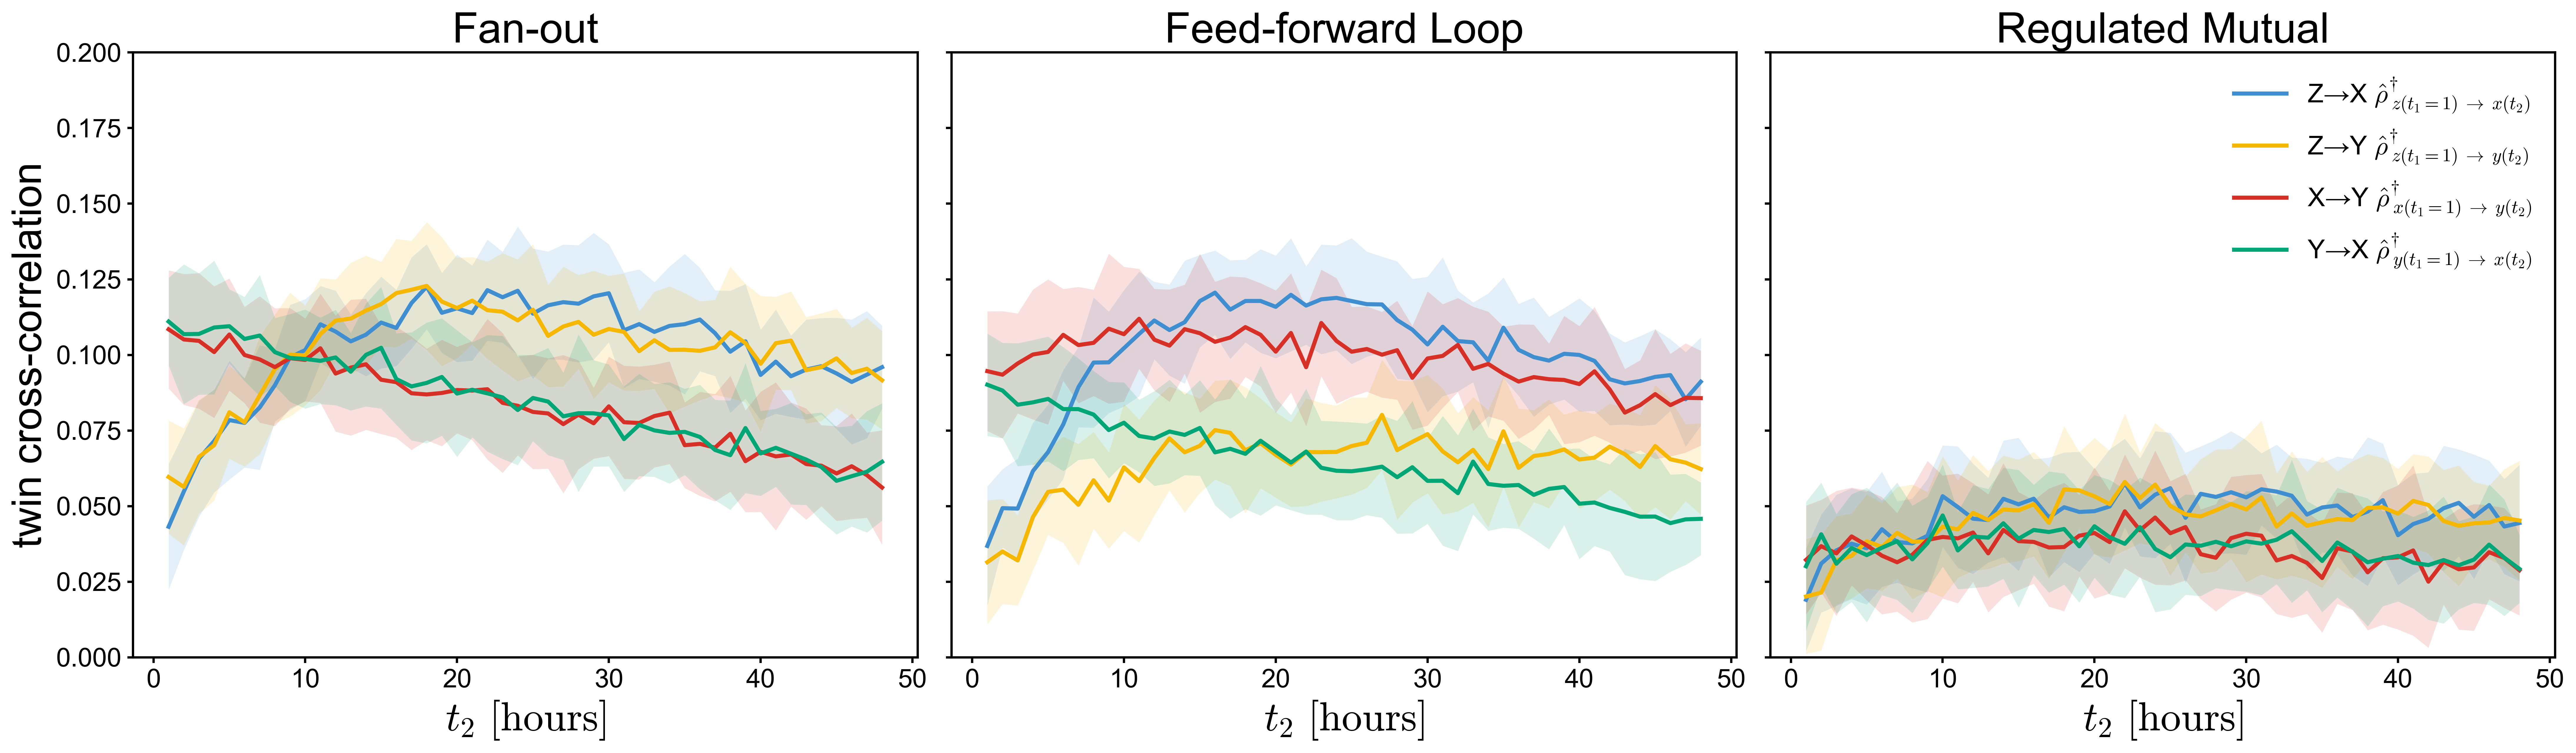

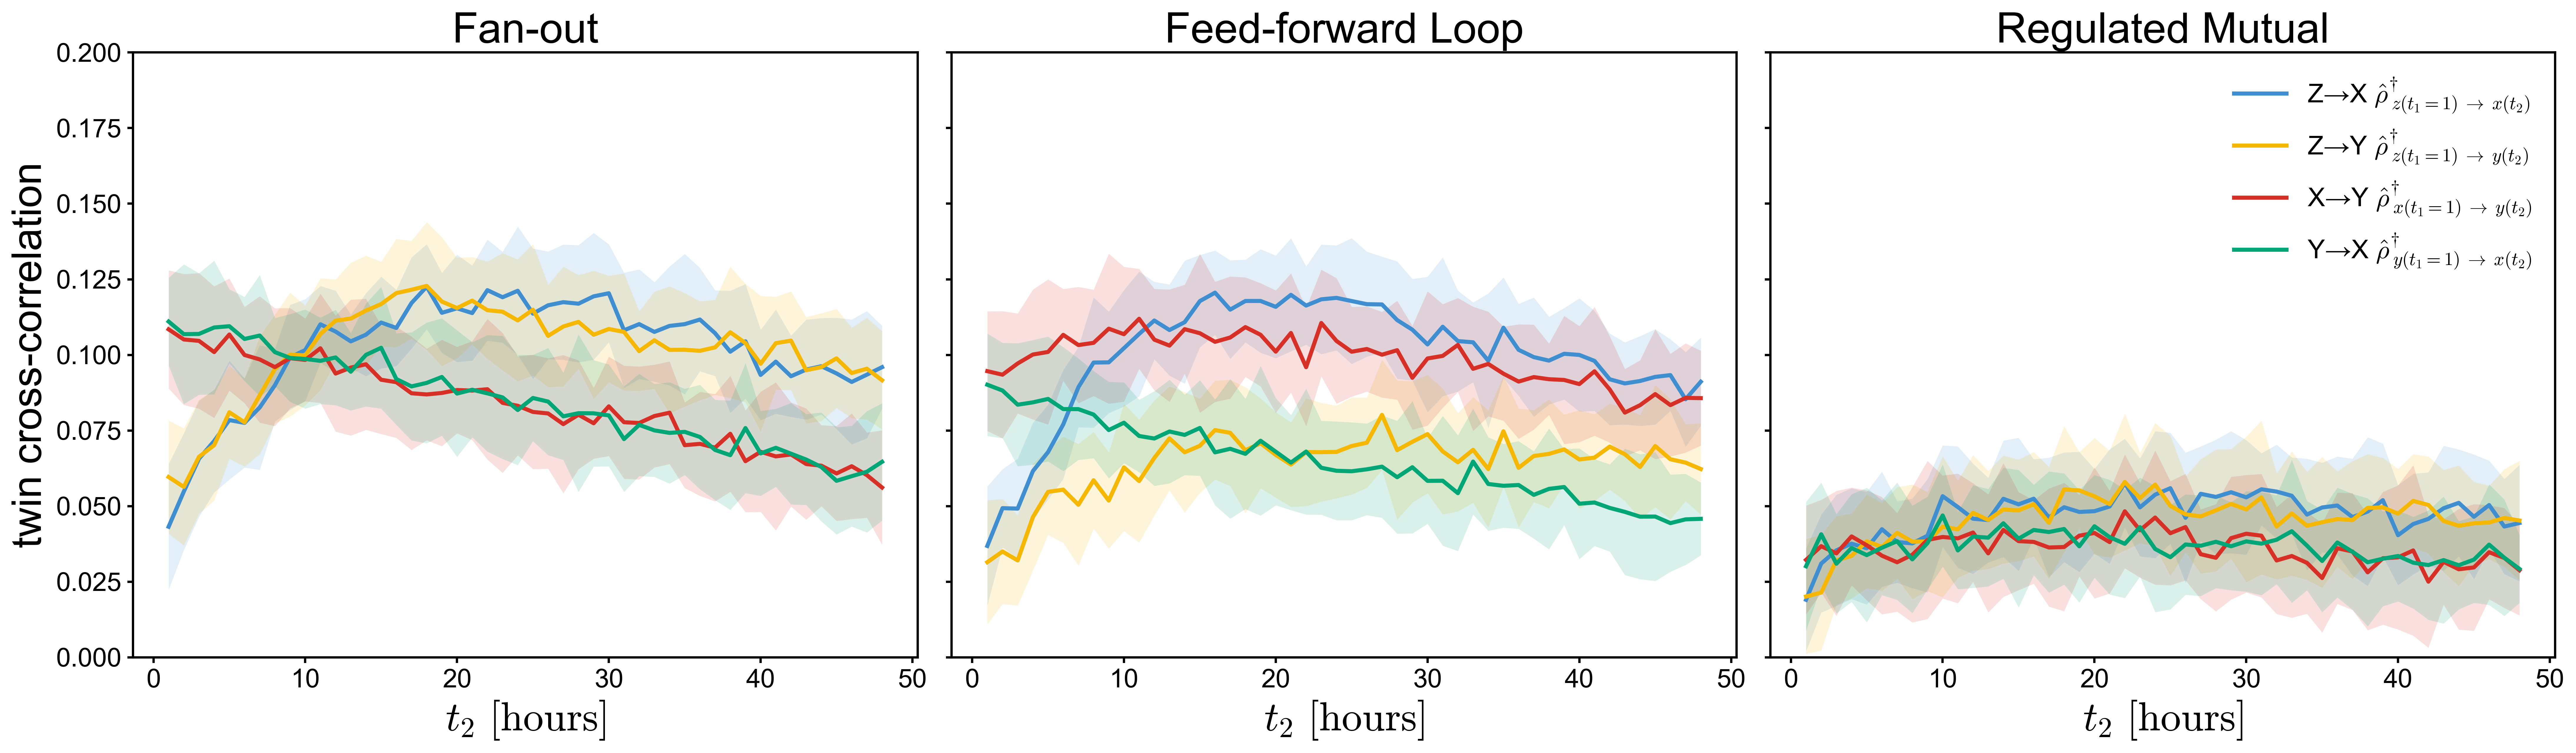

In [13]:
t1_fixed = 1
t2_values = list(range(1, 49))   # 1..48
time_col = 'time_step'

# Colors
COL_ZX = "#3E8ED0"
COL_ZY = "#F5B700"
COL_XY = "#D73027"
COL_YX = "#00A676"

# Gene columns (Z, X, Y)
y_col  = 'gene_1_mRNA'  # Z
x1_col = 'gene_2_mRNA'  # X
x2_col = 'gene_3_mRNA'  # Y

# Metrics to compute / plot
METRICS_TO_PLOT = ["Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]

# Label the genes as Z, X, Y (for legend text)
GENE_LABELS = {y_col: "Z", x1_col: "X", x2_col: "Y"}

# Pair order (undirected pairs) and labels:
#   X-Y, Z-Y, Z-X
PAIR_ORDER  = [
    (x1_col, x2_col),   # X-Y
    (y_col,  x2_col),   # Z-Y
    (y_col,  x1_col),   # Z-X
]
PAIR_LABELS = {(a, b): f"{GENE_LABELS[a]}-{GENE_LABELS[b]}" for (a, b) in PAIR_ORDER}


MOTIF_RULES = {
    "Fan-out": {
        "include_all": ["Fan_out_additive", "df_rows"],
        "exclude_any": ["k_on0"],
        "max_files": 20,   # set int (e.g., 20) to cap newest files
    },
    "Feed-forward Loop": {
        "include_all": ["Feed_forward_additive", "df_rows"],
        "exclude_any": ["k_on0"],
        "max_files": 20,
    },
    "Regulated Mutual": {
        "include_all": ["Mutual_regulation_additive", "df_rows"],
        "exclude_any": ["k_on0"],
        "max_files": 20,
    },
}

path_to_twin_correlation = f"{path_to_plot_data}/twin_correlation_all.csv"
twin_correlation = pd.read_csv(path_to_twin_correlation)
agg_twin  = aggregate_mean_std(twin_correlation)

path_to_gene_correlation = f"{path_to_plot_data}/gene_correlation_all.csv"
gene_correlation = pd.read_csv(path_to_gene_correlation)
agg_reg  = aggregate_mean_std(gene_correlation)

name_plot = "Cross_correlation_triplet_fig4_new_additive.pdf"
motifs_order = ['Fan-out', 'Feed-forward Loop', 'Regulated Mutual']
plot_three_motifs_panels(agg_twin, agg_reg, outpath=f"{path_to_plots}/{name_plot}", motifs_order=motifs_order)


## Figure 4b

In [14]:
# Load the data
random_correlation_path = f"{path_to_plot_data}/random_matrix_results.csv"
twin_correlation_t1_path= f"{path_to_plot_data}/twin_t1_matrix_results.csv"
random_correlation_data = pd.read_csv(random_correlation_path)
twin_correlation_t1_data = pd.read_csv(twin_correlation_t1_path)

In [15]:
# Load data about twin correlation, z-scores and median of random pair correlations
loaded_df = pd.read_csv(f"{path_to_plot_data}/twins_random_zscore_summary.csv")

# Helper function: extract list for a specific network + metric
def extract_list(df, net, metric, gene_pair_set):
    return df[(df.network_type == net) & (df.metric == metric) & (df.gene_pair == gene_pair_set)]["values"].tolist()

# === Reconstruct all 9 lists ===

sim_types_to_plot = ["Fan_out", "Feed_forward", "Mutual_regulation"]
gene_pair = ("g2_g3")
Fan_out_medians  = extract_list(loaded_df, "Fan_out", "medians", "('gene_2', 'gene_3')")
Fan_out_z_scores = extract_list(loaded_df, "Fan_out", "z_scores", "('gene_2', 'gene_3')")
Fan_out_threshold = extract_list(loaded_df, "Fan_out", "z_threshold_list_neg", "('gene_2', 'gene_3')")

Feed_forward_medians = extract_list(loaded_df, "Feed_forward", "medians", "('gene_2', 'gene_3')")
Feed_forward_z_scores = extract_list(loaded_df, "Feed_forward", "z_scores","('gene_2', 'gene_3')")
Feed_forward_threshold = extract_list(loaded_df, "Feed_forward", "z_threshold_list_neg", "('gene_2', 'gene_3')")

Mutual_regulation_medians = extract_list(loaded_df, "Mutual_regulation", "medians", "('gene_2', 'gene_3')")
Mutual_regulation_z_scores = extract_list(loaded_df, "Mutual_regulation", "z_scores", "('gene_2', 'gene_3')")
Mutual_regulation_threshold = extract_list(loaded_df, "Mutual_regulation", "z_threshold_list_neg", "('gene_2', 'gene_3')")


In [16]:
# random-pair correlation medians
random_correlation_medians = [
    Fan_out_medians,
    Feed_forward_medians,
    Mutual_regulation_medians,
]
threshold_lists = [
    Fan_out_threshold,
    Feed_forward_threshold,
    Mutual_regulation_threshold
]
z_score_threshold = -12
colors = ['#194a9e', '#006937', '#ee9127']
light_colors = ['#194a9e', '#006937', '#ee9127']
# Collect data for plotting
all_data = []
all_colors = []
positions = []
z_scores = []
z_scores = [Fan_out_z_scores, Feed_forward_z_scores, Mutual_regulation_z_scores]
pos = 1
for i, sim_type in enumerate(sim_types_to_plot):
    
    # 1. Use random correlation medians
    random_vals = np.array(random_correlation_medians[i])
    random_vals = random_vals[~np.isnan(random_vals)]
    
    # 2. Get twin correlation data from CSV
    twin_sim = twin_correlation_t1_data[twin_correlation_t1_data['sim_type'] == sim_type]
    twin_vals = twin_sim[gene_pair].values  # Adjust column name if needed
    
    if len(random_vals) > 0 and len(twin_vals) > 0:
        # Calculate 1st percentile threshold from random medians        
        # Add to plotting data (random medians first, then twin)
        all_data.extend([random_vals, twin_vals])
        all_colors.extend([light_colors[i], colors[i]])
        positions.extend([pos, pos + 1])       
        pos += 3  # Space between groups
    else:
        print(f"Warning: {sim_type} missing data - Random: {len(random_vals)}, Twin: {len(twin_vals)}")


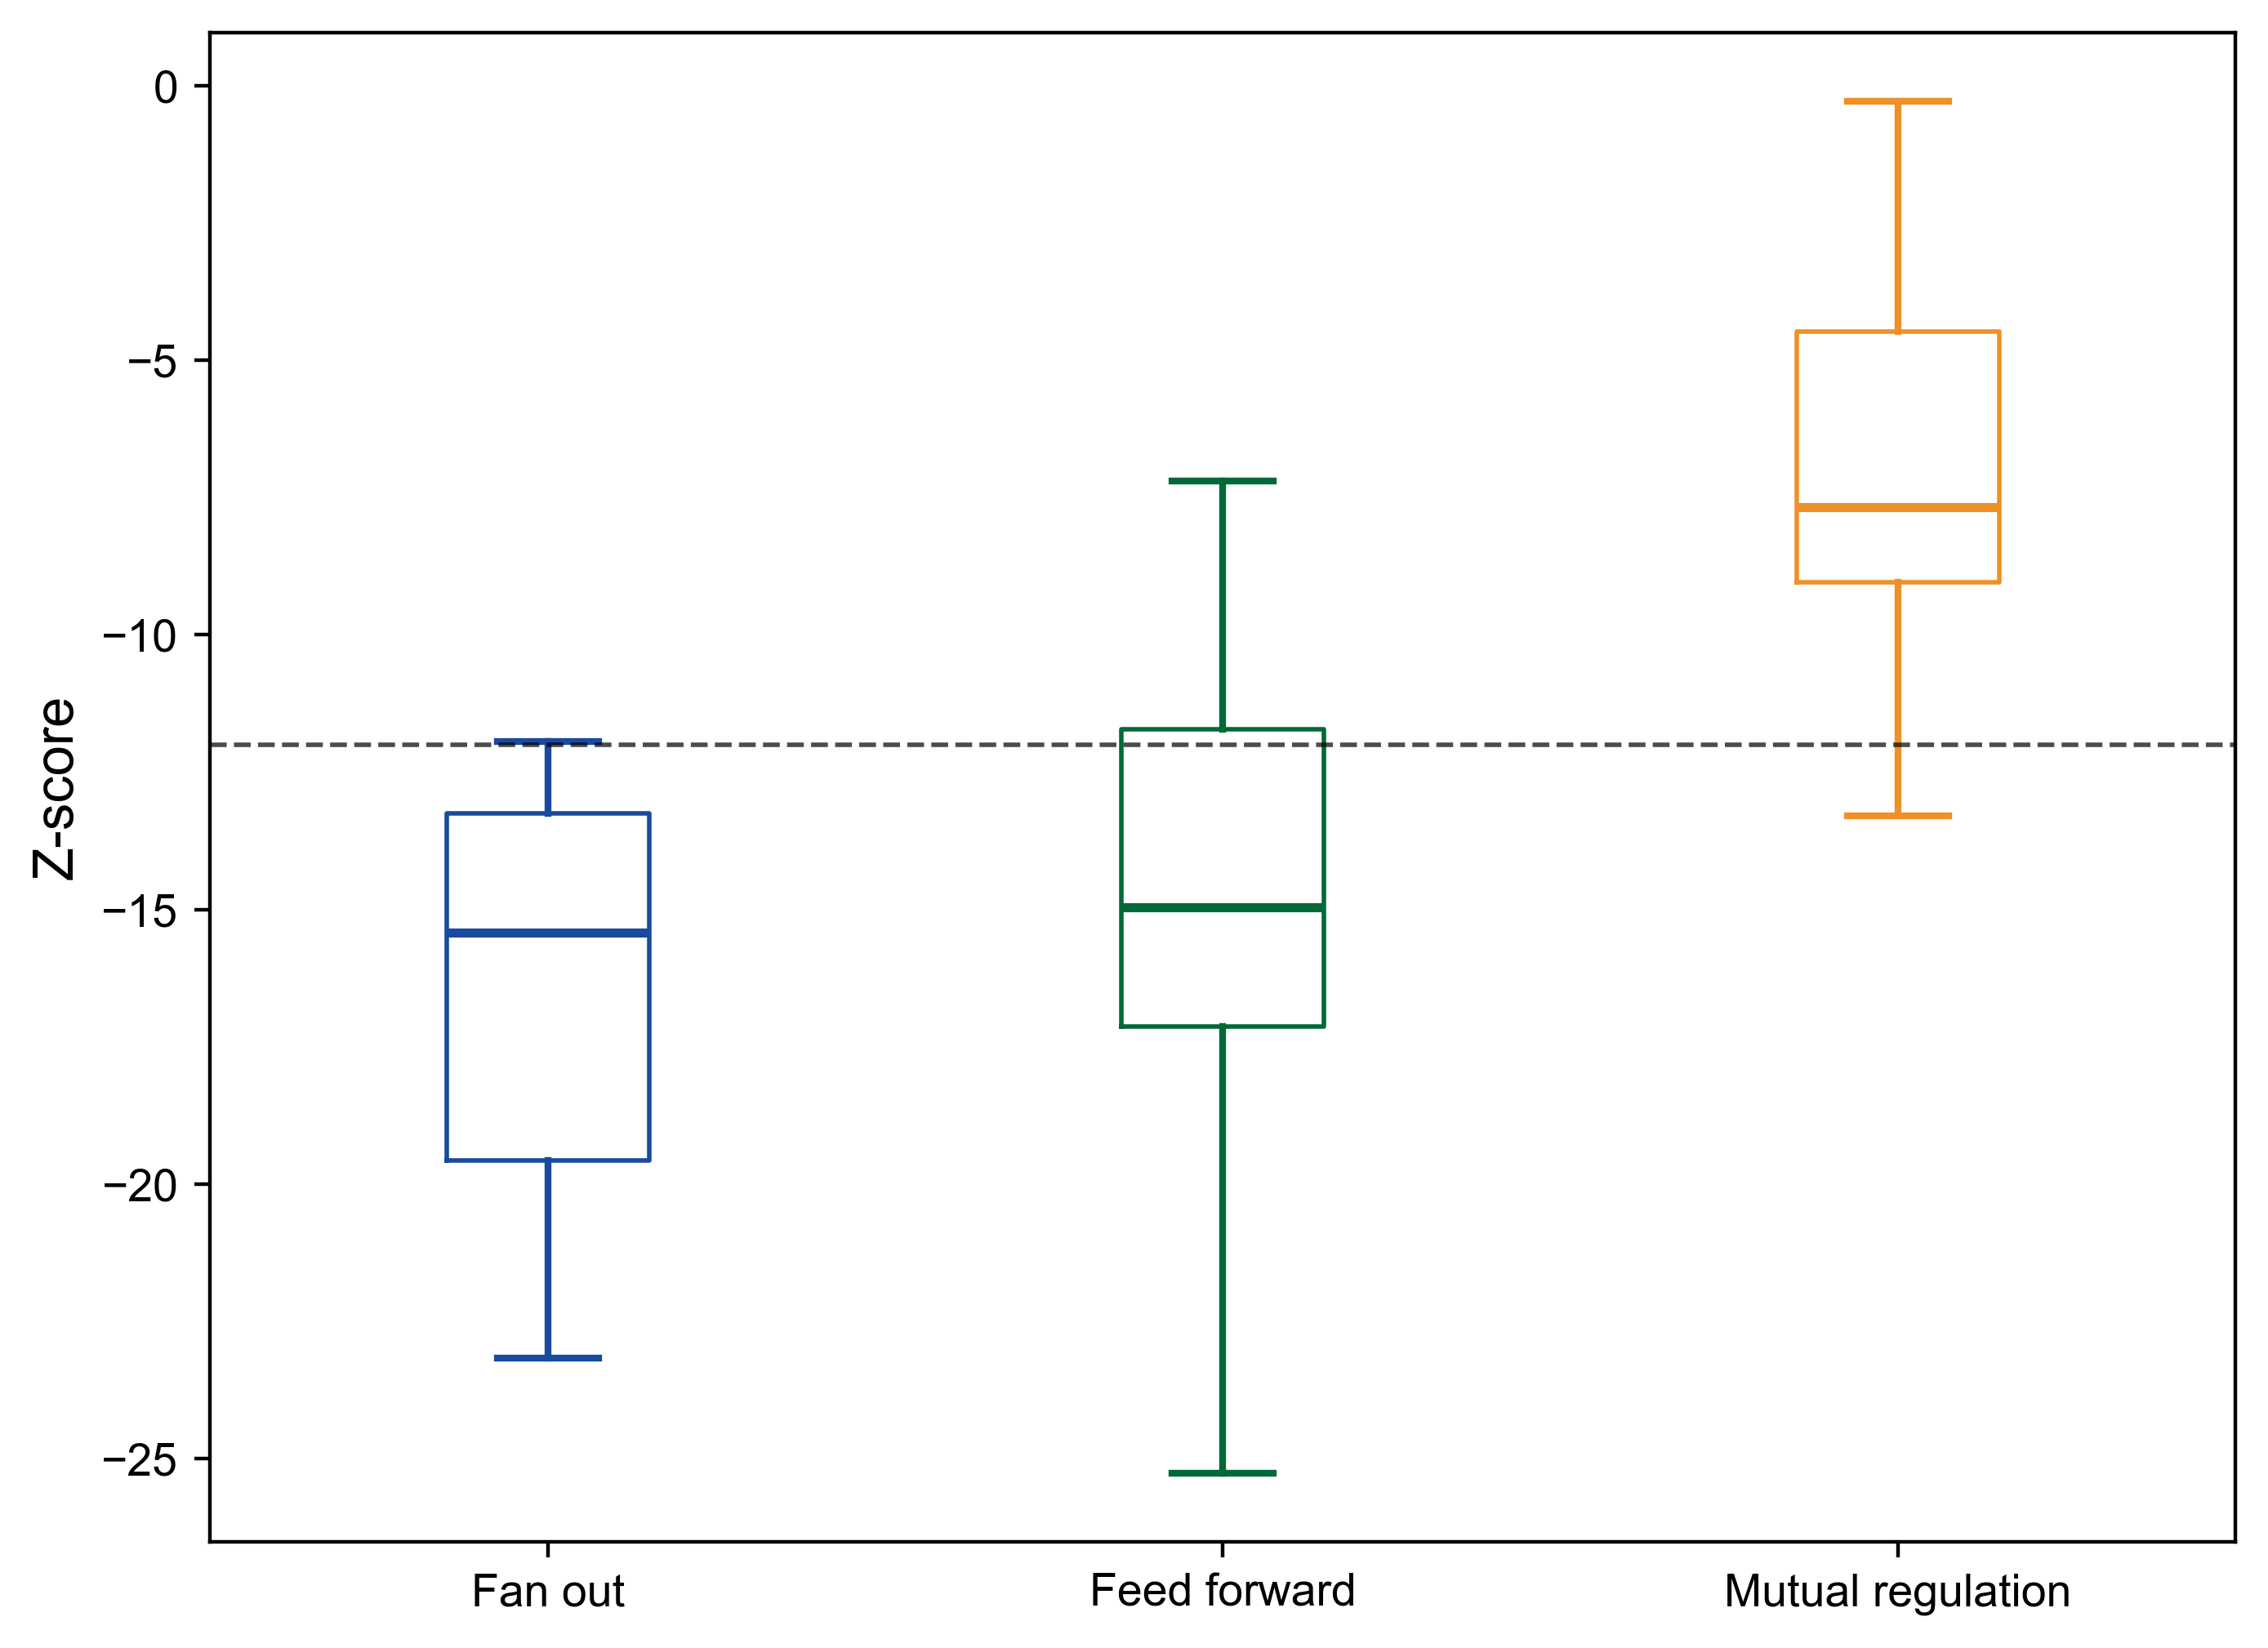

In [17]:
fig_zscore = plt.figure(figsize=(8, 6))
ax_zscore = fig_zscore.add_subplot(111)

# Create z-score boxplot using the z_scores calculated above
z_box = ax_zscore.boxplot(z_scores, patch_artist=False, showfliers=True)

# Style z-score boxplot with matching colors
for i, patch in enumerate(z_box['boxes']):
    patch.set_color(colors[i])
    patch.set_clip_on(False)

for i, median in enumerate(z_box['medians']):
    median.set_color(colors[i])
    median.set_linewidth(2)
    median.set_clip_on(False)

for i, whisker in enumerate(z_box['whiskers']):
    whisker.set_color(colors[i//2])
    whisker.set_linewidth(1.5)
    whisker.set_clip_on(False)

for i, cap in enumerate(z_box['caps']):
    cap.set_color(colors[i//2])
    cap.set_linewidth(1.5)
    cap.set_clip_on(False)

# Style outliers
for i, flier in enumerate(z_box['fliers']):
    if len(flier.get_data()[0]) > 0:
        flier.set_markerfacecolor("none")
        flier.set_markeredgecolor(colors[i])
        flier.set_markersize(4)

# Add z-score thresholds
#ax_zscore.axhline(-1*z_score_threshold, linestyle="--", color="black", linewidth=1, alpha=0.7, label="z-score threshold")
ax_zscore.axhline(z_score_threshold, linestyle="--", color="black", linewidth=1, alpha=0.7)


# Set labels and styling
ax_zscore.set_xticks([1,2,3])
ax_zscore.set_xticklabels(["Fan out", "Feed forward", "Mutual regulation"])
ax_zscore.set_ylabel("Z-score", fontsize=12)
ax_zscore.tick_params(labelsize=10)
# ax_zscore.legend(fontsize=10)

# Save z-score plot
plt.savefig(f"{path_to_plots}/zscore_boxplot_{gene_pair}.pdf", 
           format="pdf", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.savefig(f"{path_to_plots}/zscore_boxplot_{gene_pair}.svg", 
           format="svg", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.savefig(f"{path_to_plots}/zscore_boxplot_{gene_pair}.png", 
           format="png", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)

plt.show()

## Figure 4c

In [6]:
import json
path_to_plots = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_4/"
correlation = f"{path_to_plots}/figure_1_network_correlation_matrices.json"

with open(correlation, "r") as f:
    correlation_matrices = json.load(f)

print(correlation_matrices.keys())
pairwise_gene_gene_correlation_matrix = pd.DataFrame(correlation_matrices['pairwise_gene_gene_correlation_matrix'])
all_gene_pairs = correlation_matrices['all_gene_pairs']
final_directed_edges = correlation_matrices['final_directed_edges']
potential_regulation = correlation_matrices['potential_regulation']
unfiltered_direction_matrix = pd.DataFrame(correlation_matrices['unfiltered_direction_matrix'])
multiple_states_and_reg = correlation_matrices['gene_lists']['multiple_states_and_reg']

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
#Plot gene-correlation data
gene_list = sorted(
    {g for pair in all_gene_pairs for g in pair},
    key=lambda x: int(x.split("_")[1])
)
gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
pairwise_gene_gene_correlation_matrix = pairwise_gene_gene_correlation_matrix.loc[gene_list, gene_list]
data_matrix = pairwise_gene_gene_correlation_matrix.to_numpy(float)
np.fill_diagonal(data_matrix, np.nan)
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])

plot_matrix = data_matrix.copy()
plot_matrix[:] = 0.0

# Restore only potential regulation correlations
for g1, g2 in potential_regulation:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        plot_matrix[i, j] = data_matrix[i, j]
        plot_matrix[j, i] = data_matrix[j, i]
np.fill_diagonal(plot_matrix, np.nan)
vmin = -0.299
vmax = 0.299

cmap = make_reds_blues_colormap()
cmap.set_bad(color="#D9D9D9")

gene_to_label = {
    "gene_1": r"$g1$",
    "gene_2": r"$g2$",
    "gene_3": r"$g3$",
    "gene_4": r"$g4$",
    "gene_5": r"$g5$",
    "gene_6": r"$g6$",
    "gene_7": r"$g7$",
    "gene_8": r"$g8$",
    "gene_9": r"$g9$",
    "gene_10": r"$g10$",
    "gene_11": r"$g11$",
    "gene_12": r"$g12$",
    "gene_13": r"$g13$",
    "gene_14": r"$g14$",
}

plot_df = pd.DataFrame(
    plot_matrix,
    index=gene_list,
    columns=gene_list
)

sns.heatmap(
    plot_df,
    ax=heatmap_ax,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal'},
    linewidths=0.5,
    linecolor="black",
    # center=center
)

gene_to_idx = {g: i for i, g in enumerate(gene_list)}
for g1, g2 in potential_regulation:
    if g1 in gene_to_idx and g2 in gene_to_idx:
        i = gene_to_idx[g1]
        j = gene_to_idx[g2]

        for (x, y) in [(j, i), (i, j)]:
            rect = Rectangle(
                (x, y), 1, 1,
                fill=False,
                edgecolor="black",
                linewidth=1.5,
                clip_on=False
            )
            heatmap_ax.add_patch(rect)
        
cbar_ax.xaxis.set_label_position('top')
cbar_ax.set_xlabel(r"gene correlation $\rho$", labelpad=10)
cbar_ax.xaxis.tick_top()
xlabels = [gene_to_label.get(g, g) for g in plot_df.columns]
ylabels = [gene_to_label.get(g, g) for g in plot_df.index]

heatmap_ax.set_xticklabels(xlabels, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(ylabels, rotation=0, ha="right", va="center")
heatmap_ax.set_aspect("equal")
# --- transparent background ---
# plt.tight_layout()
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')
    spine.set_clip_on(False)

# --- save ---
if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)
    matrix_type = "gene_correlation"
    png_path = out / f"{matrix_type}.png"
    svg_path = out / f"{matrix_type}.svg"
    pdf_path = out / f"{matrix_type}.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
    plt.show()
# # else:
plt.show()

In [ ]:
#Plot TwINFER output
gene_list = sorted(
    {g for pair in all_gene_pairs for g in pair},
    key=lambda x: int(x.split("_")[1])
)
gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
# direction_matrix = unfiltered_direction_matrix.loc[gene_list, gene_list]
data_matrix = unfiltered_direction_matrix.to_numpy(float)
masked_matrix = np.fill_diagonal(data_matrix, np.nan)
fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])
plot_matrix = data_matrix.copy()
plot_matrix[:] = 0.0

# Restore only final-ege correlations
for g1, g2 in final_directed_edges:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        plot_matrix[i, j] = data_matrix[i, j]
        plot_matrix[j, i] = data_matrix[j, i]
np.fill_diagonal(plot_matrix, np.nan)
vmin = -0.299
vmax = 0.299
cmap = make_reds_blues_colormap()

cmap.set_bad(color="#D9D9D9")
# --- draw heatmap ---
sns.heatmap(
    plot_matrix,
    ax=heatmap_ax,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal'},
    linewidths=0.5,
    linecolor="black",
    # center=center
)
for g1, g2 in multiple_states_and_reg:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        print(i, j)

        # Draw diagonal in cell (i, j) - top-left to bottom-right
        heatmap_ax.plot(
            [j, j+1],      # x: left → right
            [i, i+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )
        
        # Draw diagonal in symmetric cell (j, i) - top-left to bottom-right
        heatmap_ax.plot(
            [i, i+1],      # x: left → right
            [j, j+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )

# --- labels ---
cbar_ax.xaxis.set_label_position('top')
cbar_ax.set_xlabel(r"$\hat{\rho}^{\dagger}_{x(d_{2}) \to y(d_{4})}$", labelpad=10)
cbar_ax.xaxis.tick_top()

heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")
# --- transparent background ---
# plt.tight_layout()
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')
    spine.set_clip_on(False)

# --- save ---
if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)
    matrix_type = "direction_correlation"
    png_path = out / f"{matrix_type}.png"
    svg_path = out / f"{matrix_type}.svg"
    pdf_path = out / f"{matrix_type}.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
    plt.show()
# # else:
plt.show()